# Laboratorio 2: 02 Cálculo de Índices Espectrales

Este notebook implementa la **Parte 2** del laboratorio, enfocándose en el cálculo de NDVI y NDBI para las imágenes Sentinel-2 procesadas del periodo 2016-2026.

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import geopandas as gpd
import sys
import re
import os

# Configuración de rutas y utilerías
sys.path.append(os.path.abspath('..'))
from scripts.calculate_indices import calcular_indices_from_zip

raw_path = Path('../data/raw')
proc_path = Path('../data/processed')
vector_path = Path('../data/vector')
proc_path.mkdir(exist_ok=True, parents=True)

## 1. Procesamiento de Rasters

Generamos archivos GeoTIFF multitemporales con 4 bandas, correspondientes a cada índice solicitado.

In [2]:
zips = sorted(list(raw_path.glob('*.zip')))
for z in zips:
    year = re.search(r'(\d{4})', z.name).group(1)
    salida = proc_path / f"indices_{year}.tif"
    if not salida.exists():
        print(f"Procesando indices para el año {year}...")
        calcular_indices_from_zip(z, salida)
    else:
        print(f"✓ Indices {year} ya existen en {salida}")

✓ Indices 2016 ya existen en ../data/processed/indices_2016.tif
✓ Indices 2023 ya existen en ../data/processed/indices_2023.tif
✓ Indices 2017 ya existen en ../data/processed/indices_2017.tif
✓ Indices 2019 ya existen en ../data/processed/indices_2019.tif
✓ Indices 2021 ya existen en ../data/processed/indices_2021.tif
✓ Indices 2026 ya existen en ../data/processed/indices_2026.tif


## 2. Estadísticas Descriptivas e Histogramas

Calculamos media y desviación estándar para cada índice y visualizamos su distribución.

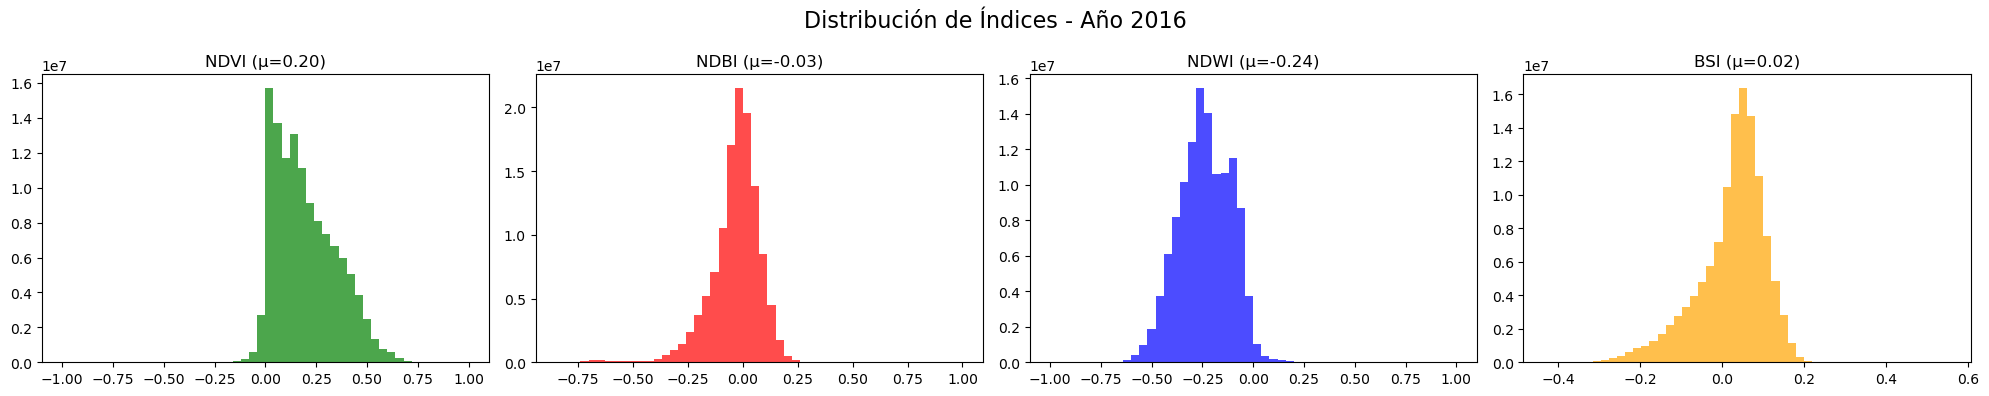

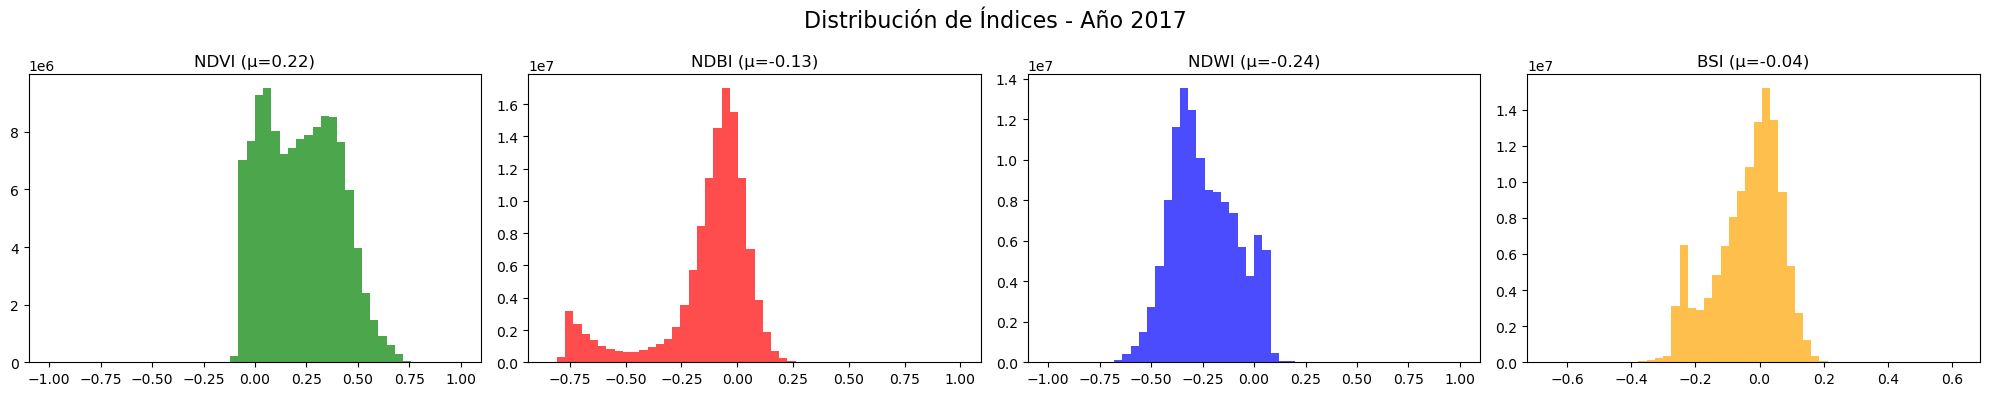

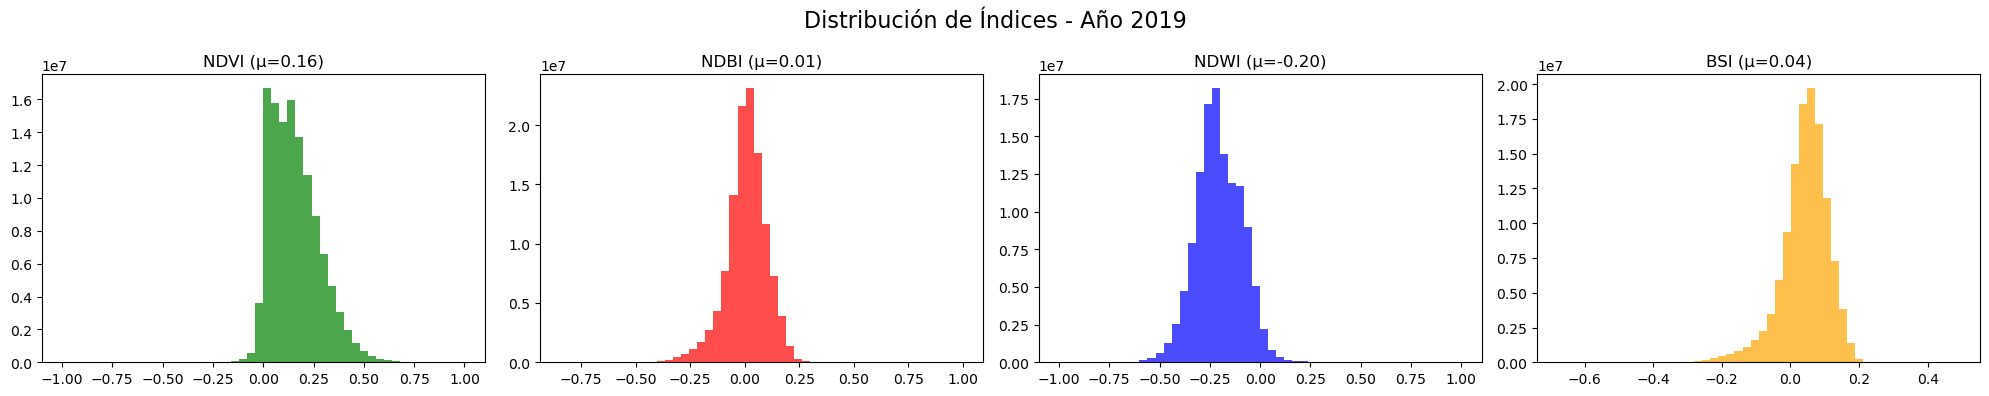

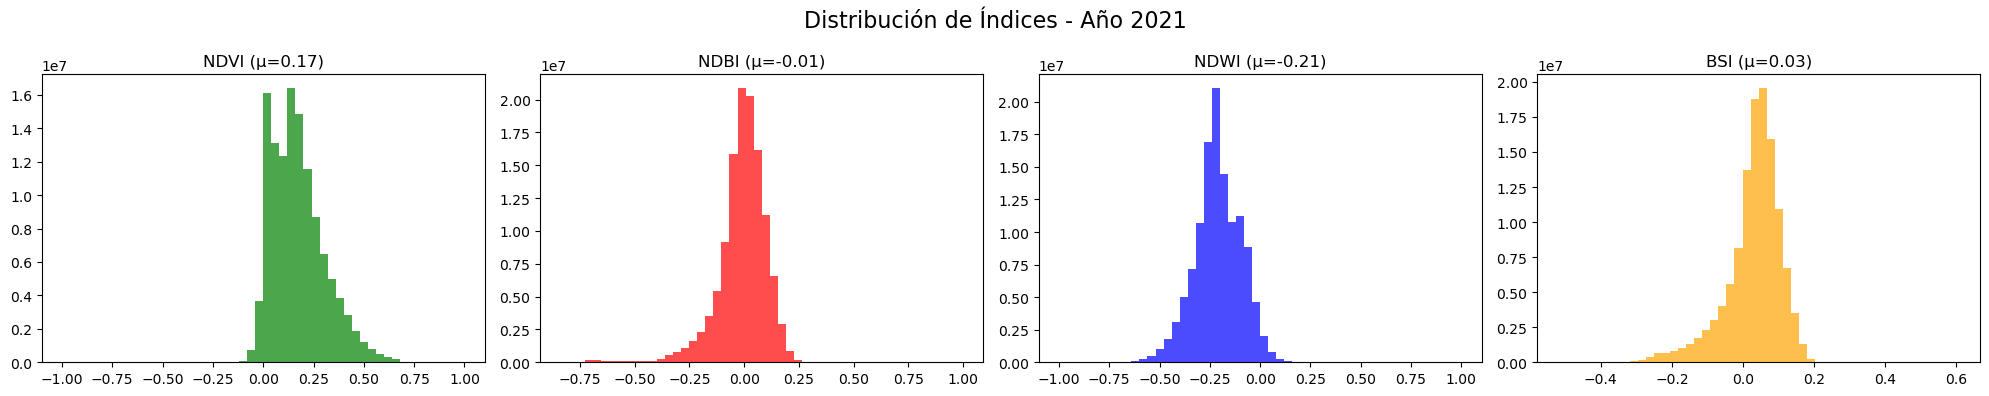

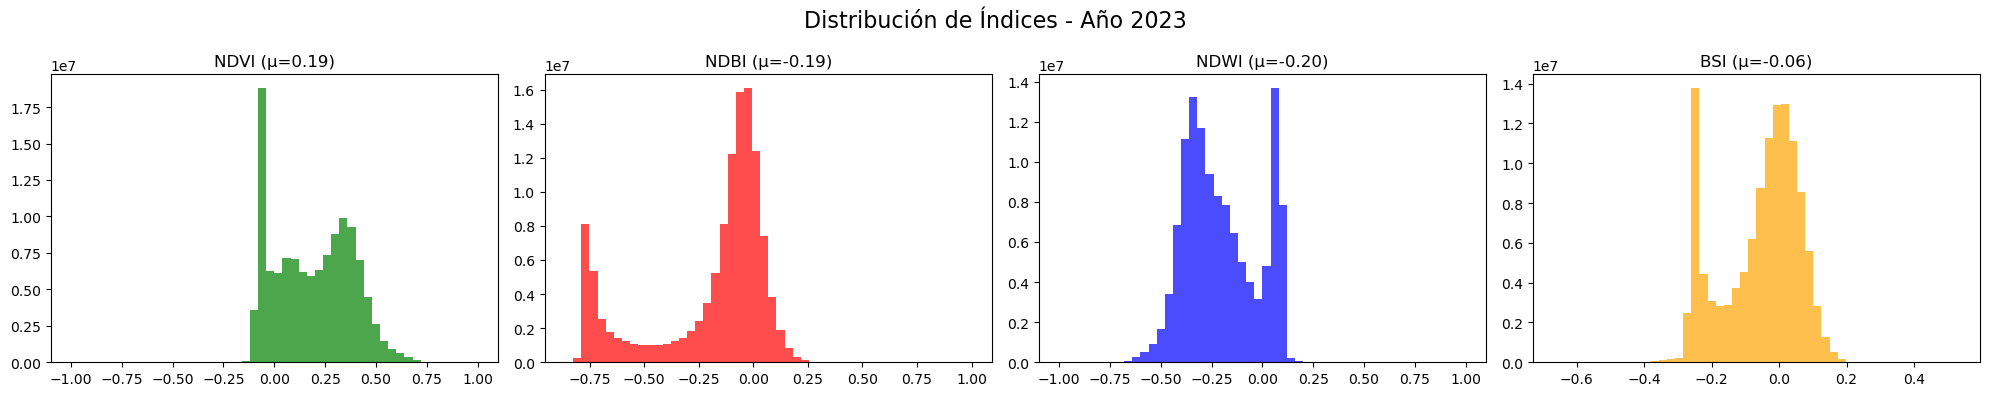

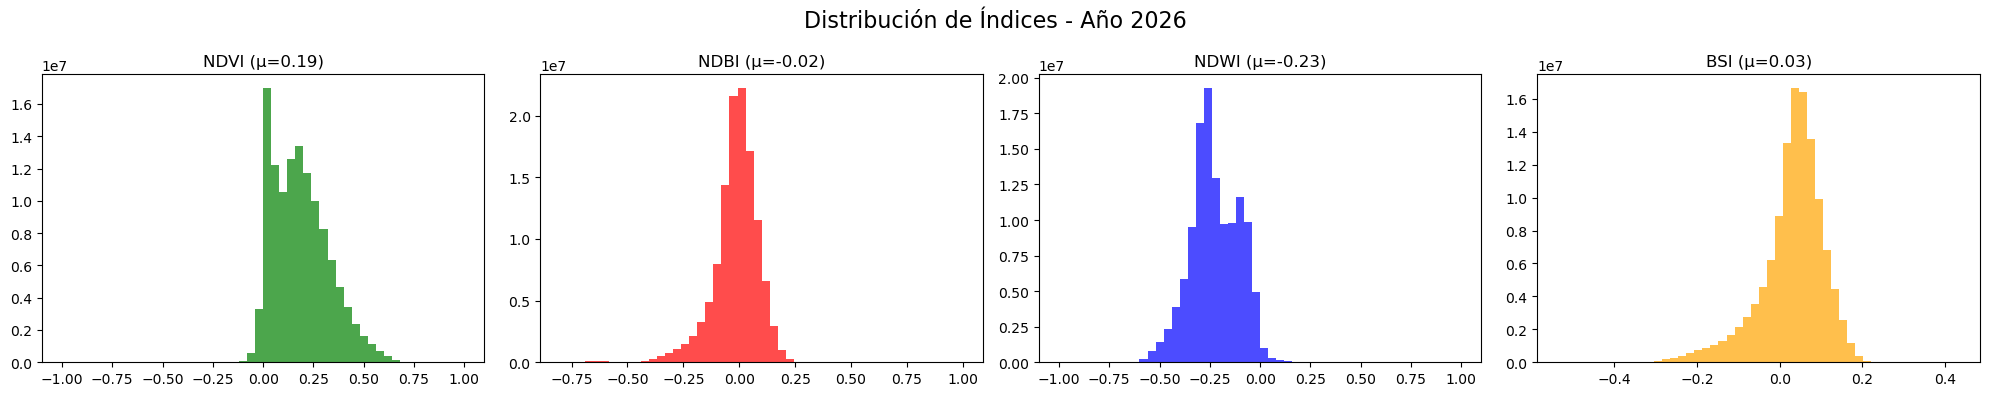

,Año,NDVI_media,NDVI_std,NDBI_media,NDBI_std,NDWI_media,NDWI_std,BSI_media,BSI_std
0,2016,0.196889,0.150620,-0.032786,0.111776,-0.236836,0.127440,0.023012,0.082013
1,2017,0.223243,0.180487,-0.134630,0.210276,-0.240728,0.158385,-0.038253,0.102817
2,2019,0.157583,0.119606,0.006669,0.095294,-0.204772,0.113581,0.042333,0.068426
3,2021,0.172396,0.130866,-0.008775,0.111277,-0.210479,0.115118,0.029475,0.076159
4,2023,0.188724,0.190263,-0.192815,0.269917,-0.200084,0.179395,-0.056726,0.114271
5,2026,0.186290,0.138606,-0.016254,0.101998,-0.226233,0.119682,0.029764,0.076511


In [3]:
indices_files = sorted(proc_path.glob('indices_*.tif'))
all_stats = []

for f in indices_files:
    year = re.search(r'\d{4}', f.name).group()
    with rasterio.open(f) as src:
        data = src.read()
        names = ['NDVI', 'NDBI', 'NDWI', 'BSI']
        colors = ['green', 'red', 'blue', 'orange']
        
        fig, axs = plt.subplots(1, 4, figsize=(20, 4))
        fig.suptitle(f"Distribución de Índices - Año {year}", fontsize=16)
        
        year_stats = {'Año': year}
        
        for i in range(4):
            band_data = data[i].flatten()
            band_data = band_data[~np.isnan(band_data)] # Eliminar NaNs para el histograma
            
            # Stats
            mean_val = np.mean(band_data)
            std_val = np.std(band_data)
            year_stats[f'{names[i]}_media'] = mean_val
            year_stats[f'{names[i]}_std'] = std_val
            
            # Plot
            axs[i].hist(band_data, bins=50, color=colors[i], alpha=0.7)
            axs[i].set_title(f"{names[i]} (μ={mean_val:.2f})")
            
        all_stats.append(year_stats)
        plt.tight_layout()
        plt.show()

df_stats = pd.DataFrame(all_stats)
df_stats.to_csv(proc_path / 'estadisticas_completas.csv', index=False)
display(df_stats)

## 3. Visualización Comparativa (Zoom San Bernardo)

Muestra el crecimiento de la mancha urbana (NDBI) entre el inicio y el fin del periodo de estudio.

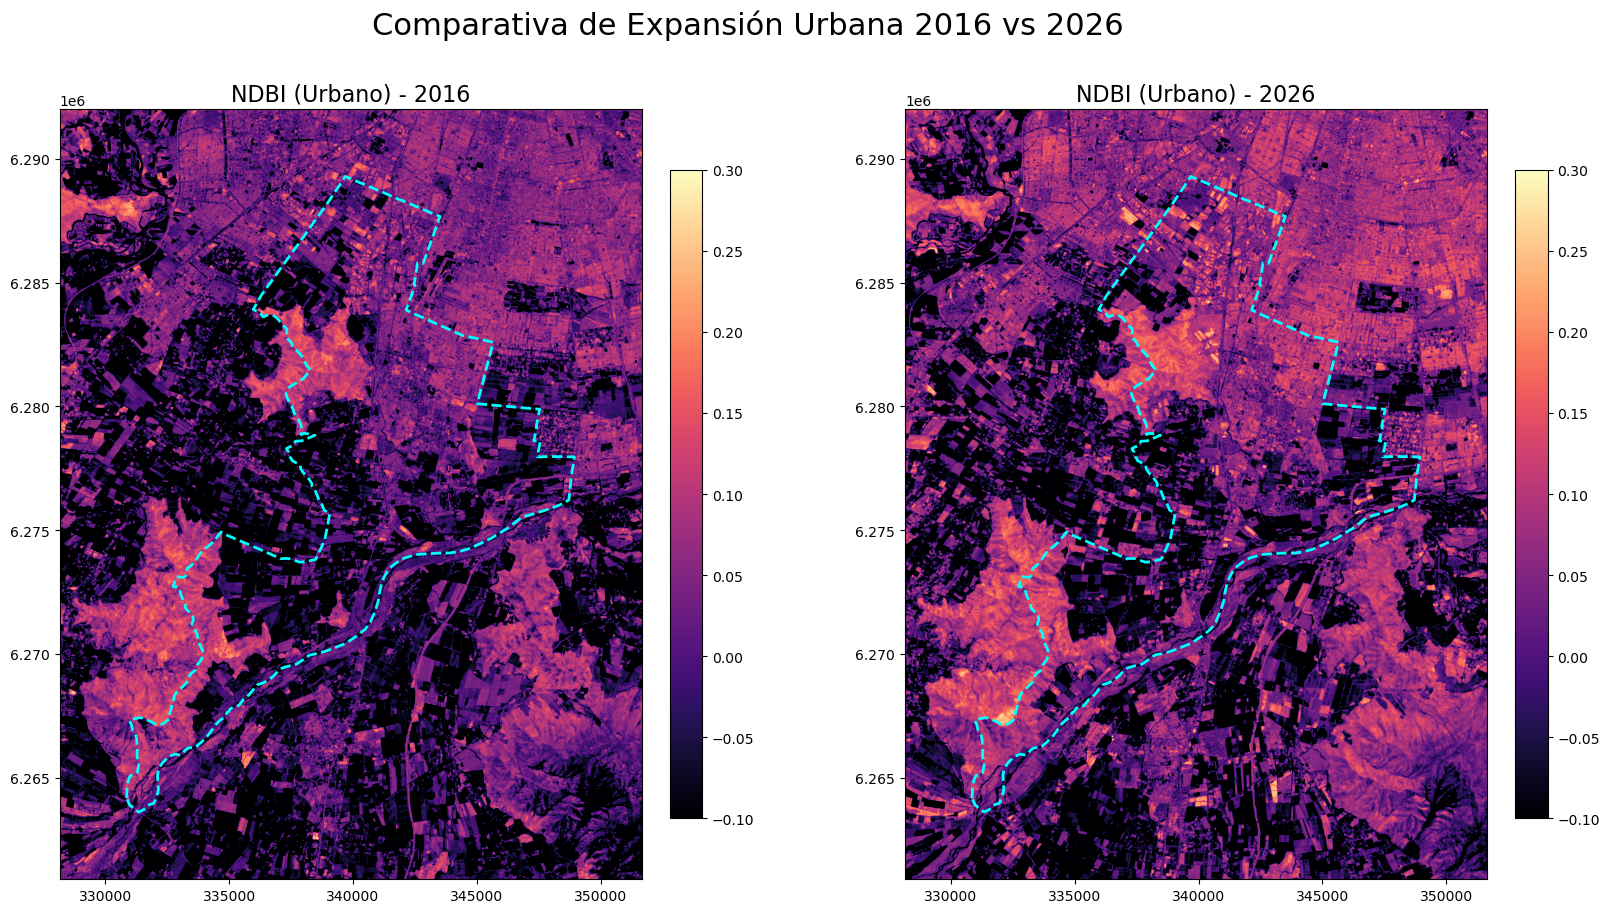

In [4]:
boundary_path = vector_path / 'limite_comuna.gpkg'
if len(indices_files) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    gdf_boundary = gpd.read_file(boundary_path) if boundary_path.exists() else None
    
    files_to_compare = [indices_files[0], indices_files[-1]]
    axs = [ax1, ax2]
    
    for i, f in enumerate(files_to_compare):
        year = re.search(r'\d{4}', f.name).group()
        with rasterio.open(f) as src:
            # Zoom logic
            if gdf_boundary is not None:
                gdf_local = gdf_boundary.to_crs(src.crs)
                minx, miny, maxx, maxy = gdf_local.total_bounds
                margin = (maxx - minx) * 0.15
                bbox = [minx - margin, miny - margin, maxx + margin, maxy + margin]
            else:
                bbox = [src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top]
            
            img = axs[i].imshow(src.read(2), cmap='magma', vmin=-0.1, vmax=0.3, 
                                extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])
            axs[i].set_xlim(bbox[0], bbox[2])
            axs[i].set_ylim(bbox[1], bbox[3])
            axs[i].set_title(f"NDBI (Urbano) - {year}", fontsize=16)
            
            if gdf_boundary is not None:
                gdf_local.plot(ax=axs[i], edgecolor='cyan', facecolor='none', linestyle='--', linewidth=2)
            
            fig.colorbar(img, ax=axs[i], fraction=0.046, pad=0.04)
            
    plt.suptitle("Comparativa de Expansión Urbana 2016 vs 2026", fontsize=22)
    plt.show()